# Preprocessing Phase

In [1]:
import pandas as pd

def load_data(path):
    df = pd.read_csv(path)
    return df

In [2]:
def clean_data(df):
    df = df.drop_duplicates()
    df = df.dropna(subset=['UsedAgain'])
    df['SessionLengthMin'] = df['SessionLengthMin'].fillna(0)
    return df

In [3]:
def feature_engineer(df):
    df['SessionDate'] = pd.to_datetime(df['SessionDate'])
    df['SessionMonth'] = df['SessionDate'].dt.month
    df['SessionDay'] = df['SessionDate'].dt.day_name()
    df['Promts_Per_Min'] = df['TotalPrompts'] / df['SessionLengthMin'].replace(0,1)
    df['duration_bin'] = pd.cut(df['SessionLengthMin'], bins=[0,5,15,30,60,999], labels=['0-5','6-15','16-30','31-60','60+'])
    top_disc = df['Discipline'].value_counts().nlargest(10).index
    df['Discipline_mod'] = df['Discipline'].where(df['Discipline'].isin(top_disc), 'Other')
    level_map = {'High School':0, 'Undergraduate':1, 'Graduate':2}
    df['StudentLevel_ord'] = df['StudentLevel'].map(level_map)
    return df

## Visualize preprocessing changes

This section compares the raw data with the cleaned and feature-engineered version before moving on to modeling.

<Figure size 1000x400 with 0 Axes>

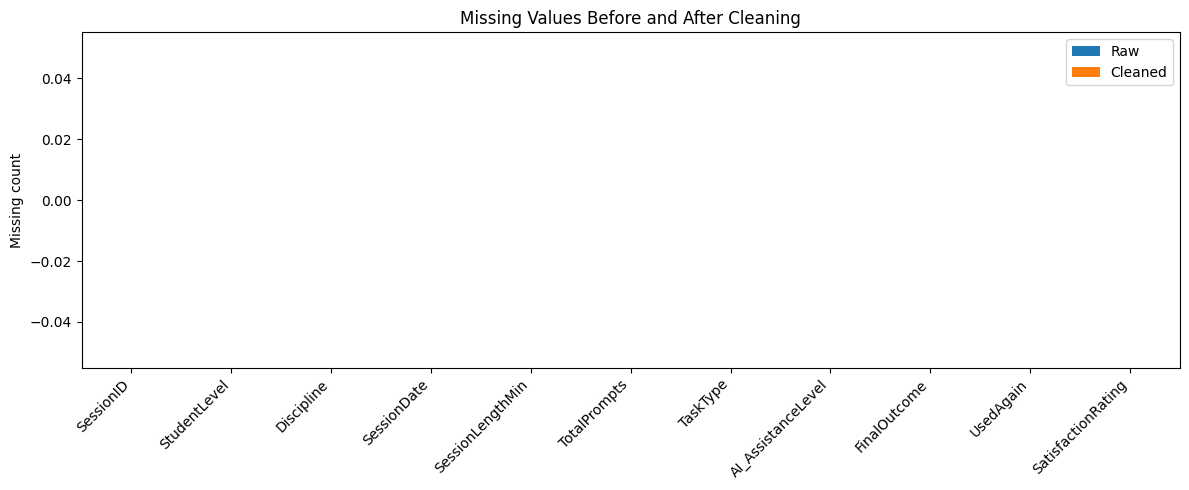

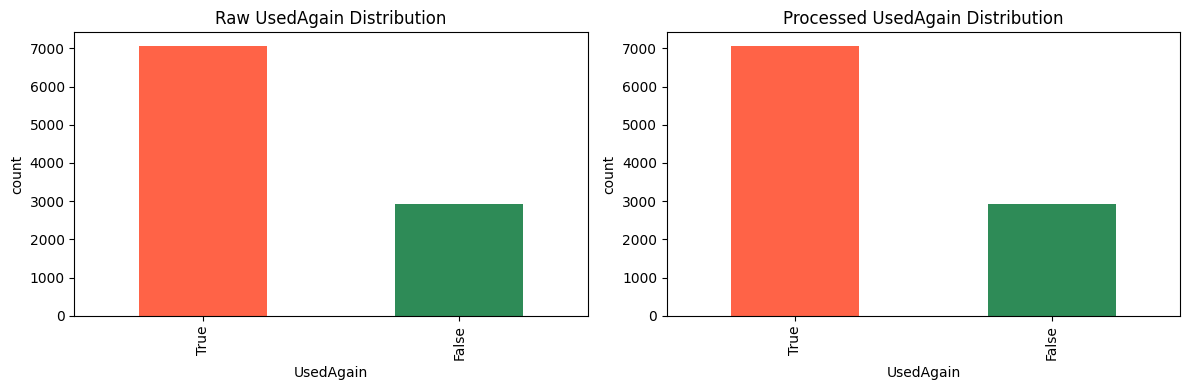

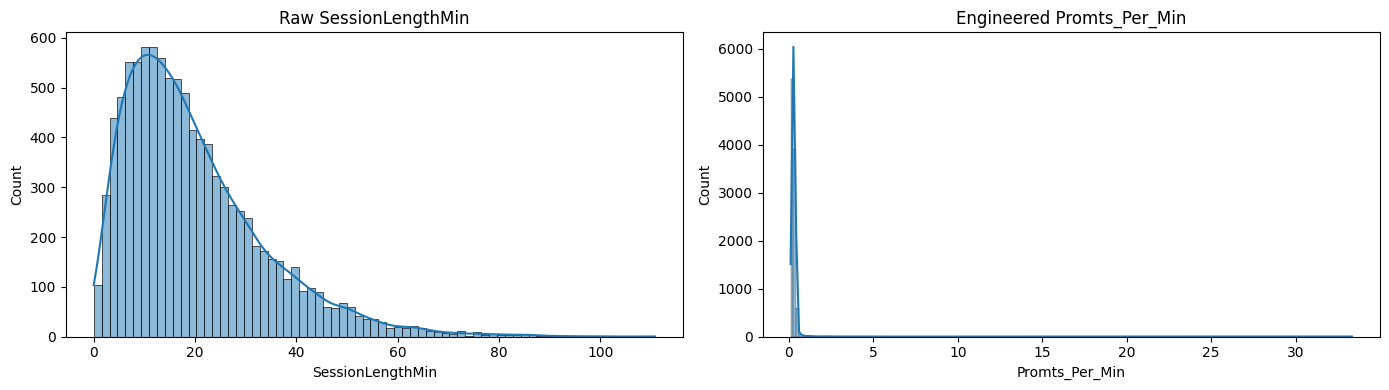

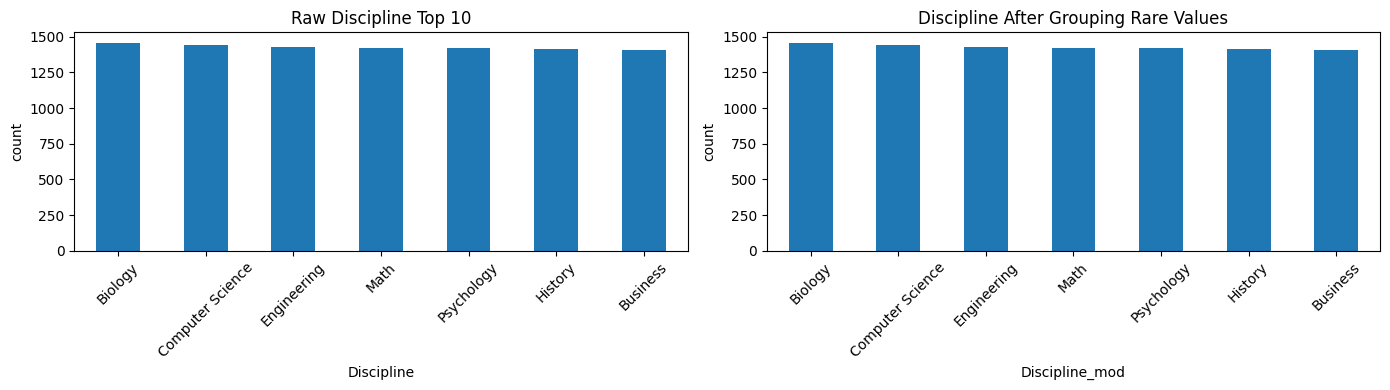

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load and prepare three versions of the data for comparison
raw_df = load_data('../data/ai_assistant_usage_student_life.csv')
clean_df = clean_data(raw_df.copy())
feat_df = feature_engineer(clean_df.copy())

# 1) Missing values before and after cleaning
plt.figure(figsize=(10, 4))
missing_counts = pd.DataFrame({
    'Raw': raw_df.isna().sum(),
    'Cleaned': clean_df.isna().sum(),
})
missing_counts.plot(kind='bar', figsize=(12, 5))
plt.title('Missing Values Before and After Cleaning')
plt.ylabel('Missing count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2) Target distribution stays visible through preprocessing
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
raw_df['UsedAgain'].value_counts().plot(kind='bar', ax=axes[0], title='Raw UsedAgain Distribution', color=['tomato', 'seagreen'])
feat_df['UsedAgain'].value_counts().plot(kind='bar', ax=axes[1], title='Processed UsedAgain Distribution', color=['tomato', 'seagreen'])
for ax in axes:
    ax.set_ylabel('count')
plt.tight_layout()
plt.show()

# 3) Numeric feature change: session length and prompts per minute
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(raw_df['SessionLengthMin'], kde=True, ax=axes[0])
axes[0].set_title('Raw SessionLengthMin')
sns.histplot(feat_df['Promts_Per_Min'], kde=True, ax=axes[1])
axes[1].set_title('Engineered Promts_Per_Min')
plt.tight_layout()
plt.show()

# 4) Category consolidation example
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
raw_df['Discipline'].value_counts().head(10).plot(kind='bar', ax=axes[0], title='Raw Discipline Top 10')
feat_df['Discipline_mod'].value_counts().head(10).plot(kind='bar', ax=axes[1], title='Discipline After Grouping Rare Values')
for ax in axes:
    ax.set_ylabel('count')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = ['SessionLengthMin', 'TotalPrompts', 'prompts_per_min']
categorical_features = ['Discipline_mod', 'TaskType_mod', 'duration_bin']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [9]:
from pathlib import Path

# Save the feature-engineered dataset for the next phase
df_processed = feat_df.copy()

output_data = Path('../data/processed.csv')
output_data.parent.mkdir(parents=True, exist_ok=True)
df_processed.to_csv(output_data, index=False)

print(f'Saved processed data to: {output_data}')

Saved processed data to: ..\data\processed.csv
